In [1]:
from langgraph.graph import StateGraph, START, END
from spm_agent.states.pfm_experiment_state import PFMExperimentState

from spm_agent.nodes.preflight_node import preflight_node
from spm_agent.nodes.sync_status_node import sync_status_node
from spm_agent.nodes.scanner_calibration_node import get_scanner_calibrations_node
from spm_agent.nodes.decision_node import experiment_decision_node
from spm_agent.nodes.scan_plan_node import scan_plan_node

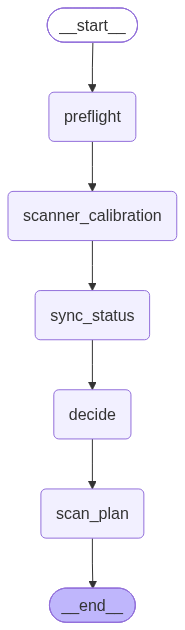

In [2]:



g = StateGraph(PFMExperimentState)
g.add_node("preflight", preflight_node)
g.add_node("scanner_calibration", get_scanner_calibrations_node)
g.add_node("sync_status", sync_status_node)
g.add_node("decide", experiment_decision_node)
g.add_node("scan_plan", scan_plan_node)

g.add_edge(START, "preflight")
g.add_edge("preflight", "scanner_calibration")
g.add_edge("scanner_calibration", "sync_status")
g.add_edge("sync_status", "decide")
g.add_edge("decide", "scan_plan")
g.add_edge("scan_plan", END)

fin_gr = g.compile()
fin_gr

In [3]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
]

EXPERIMENT_CONTEXT = (
        "This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the "
        "contact resonance.  "
)

In [4]:
res = await fin_gr.ainvoke(
    {"experiment_tasks": EXPERIMENT_TASKS, "experiment_context": EXPERIMENT_CONTEXT})

[preflight] dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260811' | frame 7.0 um @ 256 px | f_DART 375.4 kHz | V_ac 0.5 V | feedback False
[scan_plan] first scan — operator settings adopted


In [5]:
res

{'session_info': {'run_dir': 'C:\\Users\\Asylum User\\Documents\\GitHub\\SPM_agent_simple\\src\\runs\\20260812_180701',
  'started_ts': 1786572421.6432168,
  'instrument_directory': 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260811'},
 'instrument_state': InstrumentState(scan_settings=ScanSettings(x_scan_center_m=0.0, y_scan_center_m=0.0, scan_size_m=7.0000001e-06, pixels=256, scan_rate_hz=0.70067263), probe_position=ProbePosition(x_m=0.0, y_m=0.0), pfm_excitation=PFMExcitation(drive_amplitude_v=0.5, drive_frequency_hz=375395.56, dart_igain=500.0, dart_width_hz=10000.0), contact_feedback=ContactFeedback(setpoint_v=0.0, gain=10.0)),
 'scanner_calibrations': ScannerCalibrations(x_scanner_offset_m=-1.7972080222395838e-05, y_scanner_offset_m=1.5547959992315857e-05, x_lvdt_sens_m_per_v=9.2639584e-06, y_lvdt_sens_m_per_v=9.9031586e-06),
 'experiment_tasks': ['Compare switching inside domains vs near domain walls'],
 'experiment_context': 'This is Dual AC Resonance Tracking (DA

In [6]:
res

{'session_info': {'run_dir': 'C:\\Users\\Asylum User\\Documents\\GitHub\\SPM_agent_simple\\src\\runs\\20260812_174915',
  'started_ts': 1786571355.0571918,
  'instrument_directory': 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260811'},
 'instrument_state': InstrumentState(scan_settings=ScanSettings(x_scan_center_m=0.0, y_scan_center_m=0.0, scan_size_m=7.0000001e-06, pixels=256, scan_rate_hz=0.70067263), probe_position=ProbePosition(x_m=0.0, y_m=0.0), pfm_excitation=PFMExcitation(drive_amplitude_v=0.5, drive_frequency_hz=375395.56, dart_igain=500.0, dart_width_hz=10000.0), contact_feedback=ContactFeedback(setpoint_v=0.0, gain=10.0)),
 'scanner_calibrations': ScannerCalibrations(x_scanner_offset_m=-1.7972080222395838e-05, y_scanner_offset_m=1.5547959992315857e-05, x_lvdt_sens_m_per_v=9.2639584e-06, y_lvdt_sens_m_per_v=9.9031586e-06),
 'experiment_tasks': ['Compare switching inside domains vs near domain walls'],
 'experiment_context': 'This is Dual AC Resonance Tracking (DA

In [13]:
from spm_agent.prompts.scan_plan_prompt import build_scan_plan_human_message, build_scan_plan_system_message
from spm_agent.config import LOCKED_BY_HOLD

In [14]:
hm = build_scan_plan_human_message(res, locked=LOCKED_BY_HOLD)

In [15]:
from pprint import pprint
pprint(hm.text)

('EXPERIMENT TASK: Compare switching inside domains vs near domain walls\n'
 '\n'
 'DECISION: action=scan, frame_action=hold\n'
 '      understanding: (deterministic guard)\n'
 '      open questions: \n'
 '      reasoning: No image measured yet; a scan is required first.\n'
 '\n'
 'CURRENT INSTRUMENT SETTINGS\n'
 '      frame     : 7.00 um @ 256 px (27.3 nm/px), centre (+0.000, +0.000) um, '
 '0.701 Hz (~365 s per image)\n'
 '      excitation: v_ac 0.500 V, f_DART 375.4 kHz, width 10.0 kHz, dart_igain '
 '500\n'
 '      contact   : setpoint 0.000 V, igain 10   (reported only, not '
 'settable)\n'
 '\n'
 'PREVIOUS SCANS (requested -> achieved -> outcome)\n'
 '  none\n'
 '\n'
 'FRAME: The frame is unchanged. Set only acquisition quality parameters.\n'
 'LOCKED — copy these unchanged from CURRENT INSTRUMENT SETTINGS: '
 'x_scan_center_m, y_scan_center_m, scan_size_m')


In [10]:
sm = build_scan_plan_system_message()

In [11]:
pprint(sm.text)

('You are the microscopist configuring the next DART-PFM scan. A separate '
 'decision step has already chosen WHAT to measure and WHERE; you choose '
 'acquisition parameters to measure it.\n'
 '\n'
 'You receive: the decision and its reasoning, the current instrument '
 'settings, and for each previous scan what was requested, what the instrument '
 'actually ran with, and how that scan turned out — channel statistics, '
 'channel-recommendation warnings, and segmentation coverage. Preview images '
 'of the most recent scan are attached.\n'
 '\n'
 'Return the parameters you want to use for the next scan. Restate every '
 'field, copying unchanged the ones you do not intend to move. Locked fields '
 'are listed in the input; a plan that changes them is rejected.\n'
 '\n'
 'Your levers, and what they trade:\n'
 '  drive_amplitude_v — PFM response scales with it. Too low leaves the '
 'amplitude in the noise floor; too high can perturb or write domains while '
 'imaging.\n'
 '  pixels —